**Objective:**

We are dealing with multiple `stationID` values occurring at the same `connectionTime` and outliers in the `KWhDelivered`, `total_charging_time`, and `idle_time` variables in this notebook. Also used Isolation Forest for Anomaly Detection.

**Input**: `df_caltech_data_clean_NoUser.csv`

**Output**: `acn_caltech_0.2_0.1_with_stationID_22_06_2023.csv`

**Reference**:`16/03/2023 caltech TCN stationID part-1.ipynb`

# Mounting and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/notebook/data_processing/base_model/")
!ls

19062023_caltech_data_preprocessing_with_stationID_part_1.ipynb
19062023_caltech_jpl_data_preprocessing_without_stationID_part_2.ipynb
19062023_jpl_data_preprocessing_with_stationID_part_1.ipynb


In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import IsolationForest

SEED = 42
np.random.seed(SEED)

# Reading the CSV

In [ ]:
df_caltech = pd.read_csv('../../../data/preprocessed/ACN/df_caltech_data_clean_NoUser.csv')

In [ ]:
df_caltech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28184 entries, 0 to 28183
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28184 non-null  object 
 1   clusterID         28184 non-null  int64  
 2   connectionTime    28184 non-null  object 
 3   disconnectTime    28184 non-null  object 
 4   doneChargingTime  28184 non-null  object 
 5   kWhDelivered      28184 non-null  float64
 6   sessionID         28184 non-null  object 
 7   siteID            28184 non-null  int64  
 8   spaceID           28184 non-null  object 
 9   stationID         28184 non-null  object 
 10  futility_time     28184 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.4+ MB


In [ ]:
df_caltech.shape

(28184, 11)

`connectionTime` ---> start time when the EV is plugged to the EVSE
`donechargingTime` ---> when the charging is done
`disconnectTime` ---> when the EV is disconnected from the EVSE

**`connectionTime` < `donechargingTime` < `disconnectTime`**

In [ ]:
df_caltech.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,CA-319,2-39-95-27,0 days 08:12:01
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,CA-489,2-39-79-380,0 days 08:13:01
2,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,2018-04-25 16:05:22+00:00,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,CA-327,2-39-79-379,0 days 07:50:12
3,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,2018-04-25 17:40:30+00:00,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,CA-490,2-39-79-381,0 days 05:22:42
4,5bc90cb9f9af8b0d7fe77cd7,39,2018-04-25 14:43:50+00:00,2018-04-26 01:17:30+00:00,2018-04-25 16:18:28+00:00,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,CA-303,2-39-139-28,0 days 08:59:02


# Detailed Analysis and exploration with `StationID`

**Checking whether the `stationID` and `spaceID` infers the same information or not!**

In [ ]:
# group the dataframe by spaceID and stationID columns and count the number of unique values for stationID in each group
stationID_counts = df_caltech.groupby(['spaceID', 'stationID'])['stationID'].nunique()

# check if there are any groups where stationID has more than one unique value
if (stationID_counts > 1).any():
    print("There are groups where stationID has different values for the same spaceID.")
else:
    print("stationID has the same value for all rows with the same spaceID.")

stationID has the same value for all rows with the same spaceID.


**Some sanity check**

In [ ]:
# select all rows with spaceID equal to CA-319
df_ca_319 = df_caltech.loc[df_caltech['spaceID'] == 'CA-319']

# display the selected rows
df_ca_319

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,CA-319,2-39-95-27,0 days 08:12:01
50,5bc90cb9f9af8b0d7fe77d08,39,2018-04-26 02:36:02+00:00,2018-04-26 04:38:47+00:00,2018-04-26 04:34:34+00:00,11.891,2_39_95_27_2018-04-26 02:36:01.816238,2,CA-319,2-39-95-27,0 days 00:04:13
57,5bc91212f9af8b0d98ff68cb,39,2018-04-26 13:25:08+00:00,2018-04-27 01:17:37+00:00,2018-04-26 16:53:27+00:00,12.138,2_39_95_27_2018-04-26 13:25:08.191051,2,CA-319,2-39-95-27,0 days 08:24:10
102,5bc9153cf9af8b0dad3c05ed,39,2018-04-27 13:16:28+00:00,2018-04-28 01:10:32+00:00,2018-04-28 01:10:09+00:00,11.323,2_39_95_27_2018-04-27 13:16:27.810757,2,CA-319,2-39-95-27,0 days 00:00:23
156,5bc91570f9af8b0dad3c0627,39,2018-04-28 16:49:44+00:00,2018-04-28 18:52:00+00:00,2018-04-28 18:51:29+00:00,3.242,2_39_95_27_2018-04-28 16:49:43.608068,2,CA-319,2-39-95-27,0 days 00:00:31
...,...,...,...,...,...,...,...,...,...,...,...
27890,613e9d5ef9af8b53e4212168,39,2021-08-27 02:15:39+00:00,2021-08-27 03:25:48+00:00,2021-08-27 03:19:05+00:00,6.410,2_39_95_27_2021-08-27 02:15:39.265460,2,CA-319,2-39-95-27,0 days 00:06:43
28046,614d1c1ff9af8b6a7d813ddb,39,2021-09-07 16:46:20+00:00,2021-09-08 01:04:16+00:00,2021-09-07 19:35:52+00:00,9.592,2_39_95_27_2021-09-07 16:45:59.492223,2,CA-319,2-39-95-27,0 days 05:28:24
28106,614fbf18f9af8b6e5166421e,39,2021-09-09 21:15:20+00:00,2021-09-10 00:22:50+00:00,2021-09-10 00:22:46+00:00,20.406,2_39_95_27_2021-09-09 21:15:19.565507,2,CA-319,2-39-95-27,0 days 00:00:04
28129,6151109bf9af8b707a6c34ae,39,2021-09-10 16:57:17+00:00,2021-09-10 18:39:38+00:00,2021-09-10 18:39:32+00:00,5.698,2_39_95_27_2021-09-10 16:57:02.674485,2,CA-319,2-39-95-27,0 days 00:00:06


**Some sanity check**

In [ ]:
# select all rows with spaceID equal to CA-319
df_ca_489 = df_caltech.loc[df_caltech['spaceID'] == 'CA-489']

# display the selected rows
df_ca_489

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,CA-489,2-39-79-380,0 days 08:13:01
40,5bc90cb9f9af8b0d7fe77cfe,39,2018-04-26 00:02:16+00:00,2018-04-26 02:11:35+00:00,2018-04-26 02:00:58+00:00,11.466,2_39_79_380_2018-04-26 00:02:15.719927,2,CA-489,2-39-79-380,0 days 00:10:37
58,5bc91212f9af8b0d98ff68cc,39,2018-04-26 13:54:17+00:00,2018-04-26 23:08:24+00:00,2018-04-26 23:07:12+00:00,7.108,2_39_79_380_2018-04-26 13:54:16.774334,2,CA-489,2-39-79-380,0 days 00:01:12
101,5bc91212f9af8b0d98ff68f8,39,2018-04-27 05:06:13+00:00,2018-04-27 09:54:36+00:00,2018-04-27 05:25:43+00:00,0.546,2_39_79_380_2018-04-27 05:06:12.776665,2,CA-489,2-39-79-380,0 days 04:28:53
111,5bc9153cf9af8b0dad3c05f6,39,2018-04-27 15:19:27+00:00,2018-04-27 16:44:50+00:00,2018-04-27 16:28:32+00:00,3.846,2_39_79_380_2018-04-27 15:19:26.888099,2,CA-489,2-39-79-380,0 days 00:16:18
...,...,...,...,...,...,...,...,...,...,...,...
28045,614d1c1ff9af8b6a7d813dda,39,2021-09-07 16:41:47+00:00,2021-09-08 00:05:22+00:00,2021-09-07 17:40:53+00:00,3.222,2_39_79_380_2021-09-07 16:41:36.213281,2,CA-489,2-39-79-380,0 days 06:24:29
28067,614e6d9ff9af8b6c6e8d5ae3,39,2021-09-08 16:26:32+00:00,2021-09-09 01:35:09+00:00,2021-09-08 18:29:40+00:00,11.958,2_39_79_380_2021-09-08 16:26:32.474770,2,CA-489,2-39-79-380,0 days 07:05:29
28090,614fbf18f9af8b6e5166420d,39,2021-09-09 15:23:53+00:00,2021-09-09 22:30:31+00:00,2021-09-09 20:56:04+00:00,28.615,2_39_79_380_2021-09-09 15:23:43.303502,2,CA-489,2-39-79-380,0 days 01:34:27
28123,6151109bf9af8b707a6c34a8,39,2021-09-10 15:32:56+00:00,2021-09-10 23:24:42+00:00,2021-09-10 18:29:20+00:00,8.451,2_39_79_380_2021-09-10 15:32:48.986294,2,CA-489,2-39-79-380,0 days 04:55:22


**So we can drop the `spaceID`**

In [ ]:
# drop the 'spaceID' column from the df_caltech dataframe
df_caltech = df_caltech.drop('spaceID', axis=1)

In [ ]:
df_caltech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28184 entries, 0 to 28183
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28184 non-null  object 
 1   clusterID         28184 non-null  int64  
 2   connectionTime    28184 non-null  object 
 3   disconnectTime    28184 non-null  object 
 4   doneChargingTime  28184 non-null  object 
 5   kWhDelivered      28184 non-null  float64
 6   sessionID         28184 non-null  object 
 7   siteID            28184 non-null  int64  
 8   stationID         28184 non-null  object 
 9   futility_time     28184 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.2+ MB


**Checking for Unique `StationID`**

In [ ]:
# get all the unique values of the 'stationID' column in the df_caltech dataframe
unique_station_ids = df_caltech['stationID'].unique()

# display the unique values
unique_station_ids

array(['2-39-95-27', '2-39-79-380', '2-39-79-379', '2-39-79-381',
       '2-39-139-28', '2-39-91-441', '2-39-79-377', '2-39-79-382',
       '2-39-78-366', '2-39-91-437', '2-39-78-361', '2-39-78-360',
       '2-39-125-21', '2-39-78-365', '2-39-127-19', '2-39-79-383',
       '2-39-89-25', '2-39-95-444', '2-39-124-22', '2-39-89-439',
       '2-39-92-442', '2-39-123-23', '2-39-90-440', '2-39-78-364',
       '2-39-88-24', '2-39-90-26', '2-39-88-438', '2-39-78-363',
       '2-39-79-378', '2-39-123-557', '2-39-78-367', '2-39-79-376',
       '2-39-138-29', '2-39-128-18', '2-39-125-559', '2-39-126-20',
       '2-39-131-30', '2-39-130-31', '2-39-92-436', '2-39-138-566',
       '2-39-130-564', '2-39-129-17', '2-39-139-567', '2-39-127-561',
       '2-39-124-558', '2-39-129-563', '2-39-131-565', '2-39-83-386',
       '2-39-128-562', '2-39-126-560', '2-39-83-387', '2-39-82-384',
       '2-39-78-362', '2-39-82-385'], dtype=object)

In [ ]:
df_caltech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28184 entries, 0 to 28183
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28184 non-null  object 
 1   clusterID         28184 non-null  int64  
 2   connectionTime    28184 non-null  object 
 3   disconnectTime    28184 non-null  object 
 4   doneChargingTime  28184 non-null  object 
 5   kWhDelivered      28184 non-null  float64
 6   sessionID         28184 non-null  object 
 7   siteID            28184 non-null  int64  
 8   stationID         28184 non-null  object 
 9   futility_time     28184 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.2+ MB


# Some experiments `stationID`

In [ ]:
mask = df_caltech['stationID'].str.strip().str.startswith('2-39', na=False) & (df_caltech['stationID'].str.count('-') == 2)
mask
print(df_caltech['stationID'].unique())

['2-39-95-27' '2-39-79-380' '2-39-79-379' '2-39-79-381' '2-39-139-28'
 '2-39-91-441' '2-39-79-377' '2-39-79-382' '2-39-78-366' '2-39-91-437'
 '2-39-78-361' '2-39-78-360' '2-39-125-21' '2-39-78-365' '2-39-127-19'
 '2-39-79-383' '2-39-89-25' '2-39-95-444' '2-39-124-22' '2-39-89-439'
 '2-39-92-442' '2-39-123-23' '2-39-90-440' '2-39-78-364' '2-39-88-24'
 '2-39-90-26' '2-39-88-438' '2-39-78-363' '2-39-79-378' '2-39-123-557'
 '2-39-78-367' '2-39-79-376' '2-39-138-29' '2-39-128-18' '2-39-125-559'
 '2-39-126-20' '2-39-131-30' '2-39-130-31' '2-39-92-436' '2-39-138-566'
 '2-39-130-564' '2-39-129-17' '2-39-139-567' '2-39-127-561' '2-39-124-558'
 '2-39-129-563' '2-39-131-565' '2-39-83-386' '2-39-128-562' '2-39-126-560'
 '2-39-83-387' '2-39-82-384' '2-39-78-362' '2-39-82-385']


In [ ]:
# create a boolean mask of rows where stationID starts with '2-39-'
mask = df_caltech['stationID'].str.startswith('2-39-')

# display the rows where stationID starts with '2-39-'
df_caltech[mask]

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,2-39-95-27,0 days 08:12:01
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,2-39-79-380,0 days 08:13:01
2,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,2018-04-25 16:05:22+00:00,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,2-39-79-379,0 days 07:50:12
3,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,2018-04-25 17:40:30+00:00,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,2-39-79-381,0 days 05:22:42
4,5bc90cb9f9af8b0d7fe77cd7,39,2018-04-25 14:43:50+00:00,2018-04-26 01:17:30+00:00,2018-04-25 16:18:28+00:00,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,2-39-139-28,0 days 08:59:02
...,...,...,...,...,...,...,...,...,...,...
28179,61550519f9af8b76960e1697,39,2021-09-13 19:43:16+00:00,2021-09-14 01:34:43+00:00,2021-09-14 00:28:06+00:00,16.370,2_39_130_31_2021-09-13 19:43:01.675072,2,2-39-130-31,0 days 01:06:37
28180,61550519f9af8b76960e1698,39,2021-09-13 19:53:30+00:00,2021-09-13 22:33:34+00:00,2021-09-13 20:56:33+00:00,2.902,2_39_91_437_2021-09-13 19:53:30.351099,2,2-39-91-437,0 days 01:37:01
28181,61550519f9af8b76960e169a,39,2021-09-13 21:12:53+00:00,2021-09-14 00:25:36+00:00,2021-09-13 21:41:31+00:00,2.285,2_39_89_25_2021-09-13 21:12:53.318460,2,2-39-89-25,0 days 02:44:05
28182,61550519f9af8b76960e169b,39,2021-09-13 21:17:04+00:00,2021-09-14 01:01:49+00:00,2021-09-13 23:18:07+00:00,6.715,2_39_123_23_2021-09-13 21:16:44.026068,2,2-39-123-23,0 days 01:43:42


In [ ]:
# create a boolean mask of rows where the first element of stationID split by '-' is '2' and the second element is '39'
mask = (df_caltech['stationID'].str.split('-', expand=True)[0] == '2') & (df_caltech['stationID'].str.split('-', expand=True)[1] == '39')

# check if all rows satisfy the condition
if mask.all():
    print("All rows in stationID column satisfy the condition")
else:
    print("Not all rows in stationID column satisfy the condition")


All rows in stationID column satisfy the condition


**So we can remove 2-39 from the `stationID`**

In [ ]:
# create a new column stationID_New by removing '2-39-' from stationID
df_caltech['stationID'] = df_caltech['stationID'].str.replace('2-39-', '')

# print the first 5 rows of the new column
df_caltech.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,95-27,0 days 08:12:01
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,79-380,0 days 08:13:01
2,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,2018-04-25 16:05:22+00:00,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,79-379,0 days 07:50:12
3,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,2018-04-25 17:40:30+00:00,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,79-381,0 days 05:22:42
4,5bc90cb9f9af8b0d7fe77cd7,39,2018-04-25 14:43:50+00:00,2018-04-26 01:17:30+00:00,2018-04-25 16:18:28+00:00,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,139-28,0 days 08:59:02


**Convert the `stationID` into type int**

In [ ]:
# remove '-' and convert to int
df_caltech['stationID'] = df_caltech['stationID'].str.replace('-', '').astype(int)

# print the first 5 rows of the new column
df_caltech.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,9527,0 days 08:12:01
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,79380,0 days 08:13:01
2,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,2018-04-25 16:05:22+00:00,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,79379,0 days 07:50:12
3,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,2018-04-25 17:40:30+00:00,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,79381,0 days 05:22:42
4,5bc90cb9f9af8b0d7fe77cd7,39,2018-04-25 14:43:50+00:00,2018-04-26 01:17:30+00:00,2018-04-25 16:18:28+00:00,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,13928,0 days 08:59:02


**Some sanity check**

In [ ]:
# randomly select 10 rows from df_caltech
random_sample = df_caltech.sample(n=10)

# print the randomly selected rows
random_sample

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
22667,5dc4c534f9af8b0159f317d9,39,2019-10-22 16:35:45+00:00,2019-10-22 22:42:42+00:00,2019-10-22 18:11:26+00:00,4.130,2_39_90_440_2019-10-22 16:35:44.729668,2,90440,0 days 04:31:16
13761,5c2e8abbf9af8b13dab07a5c,39,2018-12-04 17:06:05+00:00,2018-12-04 18:36:06+00:00,2018-12-04 18:25:23+00:00,0.904,2_39_128_18_2018-12-04 17:06:05.064321,2,12818,0 days 00:10:43
19487,5d140e24f9af8b71c9e4cd25,39,2019-06-10 17:49:57+00:00,2019-06-10 23:48:57+00:00,2019-06-10 23:48:54+00:00,37.389,2_39_78_360_2019-06-10 17:49:53.212994,2,78360,0 days 00:00:03
25322,5e5db31ef9af8b0e9caf4bdd,39,2020-02-15 20:44:49+00:00,2020-02-15 22:03:50+00:00,2020-02-15 22:03:45+00:00,5.378,2_39_128_18_2020-02-15 20:44:48.872879,2,12818,0 days 00:00:05
3753,5bc92734f9af8b0dc677c5b1,39,2018-07-01 17:43:55+00:00,2018-07-01 18:15:54+00:00,2018-07-01 18:15:51+00:00,3.502,2_39_126_20_2018-07-01 17:43:55.228089,2,12620,0 days 00:00:03
23834,5dfd75cdf9af8b48feaa1911,39,2019-12-04 20:26:22+00:00,2019-12-05 01:58:22+00:00,2019-12-04 21:48:20+00:00,1.005,2_39_91_441_2019-12-04 20:26:21.857307,2,91441,0 days 04:10:02
9989,5bc941ddf9af8b0dc677df94,39,2018-09-28 15:36:29+00:00,2018-09-29 00:35:19+00:00,2018-09-28 17:43:10+00:00,6.006,2_39_92_436_2018-09-28 15:36:29.292602,2,92436,0 days 06:52:09
5225,5bc92d61f9af8b0dc677cbb0,39,2018-07-25 03:07:26+00:00,2018-07-25 04:31:55+00:00,2018-07-25 04:31:50+00:00,8.224,2_39_128_18_2018-07-25 03:07:26.513744,2,12818,0 days 00:00:05
516,5bc9177bf9af8b0dc677b891,39,2018-05-05 22:38:34+00:00,2018-05-06 00:48:01+00:00,2018-05-06 00:19:54+00:00,10.472,2_39_95_27_2018-05-05 22:38:34.124317,2,9527,0 days 00:28:07
25271,5e5b1034f9af8b06c4b621fa,39,2020-02-13 19:37:30+00:00,2020-02-14 02:07:10+00:00,2020-02-13 21:47:20+00:00,14.448,2_39_88_24_2020-02-13 19:37:30.281571,2,8824,0 days 04:19:50


In [ ]:
df_caltech.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28184 entries, 0 to 28183
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28184 non-null  object 
 1   clusterID         28184 non-null  int64  
 2   connectionTime    28184 non-null  object 
 3   disconnectTime    28184 non-null  object 
 4   doneChargingTime  28184 non-null  object 
 5   kWhDelivered      28184 non-null  float64
 6   sessionID         28184 non-null  object 
 7   siteID            28184 non-null  int64  
 8   stationID         28184 non-null  int64  
 9   futility_time     28184 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.2+ MB


# Timezone correction

In [ ]:
def timezonecorrection(dataframe):
    columns_tobe_converted = ['connectionTime', 'disconnectTime', 'doneChargingTime']

    for column in columns_tobe_converted:
        dataframe[column] = pd.to_datetime(dataframe[column], utc=False, errors='ignore')
        dataframe[column] = dataframe[column].map(lambda x: pd.to_datetime(x, format='%Y-%m-%d %H:%M:%S.%f', yearfirst=True).tz_convert('America/Los_Angeles'))
        dataframe[column] = dataframe[column].dt.strftime('%Y-%m-%d %H:%M:%S.%f')
        dataframe[column] = pd.to_datetime(dataframe[column])

    return dataframe

In [ ]:
caltech_dataframe = df_caltech.copy()
caltech_dataframe = timezonecorrection(caltech_dataframe)
caltech_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 06:45:10,2018-04-25 17:56:16,2018-04-25 09:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,9527,0 days 08:12:01
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 06:45:50,2018-04-25 16:04:45,2018-04-25 07:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,79380,0 days 08:13:01
2,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 07:37:06,2018-04-25 16:55:34,2018-04-25 09:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,79379,0 days 07:50:12
3,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 07:40:34,2018-04-25 16:03:12,2018-04-25 10:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,79381,0 days 05:22:42
4,5bc90cb9f9af8b0d7fe77cd7,39,2018-04-25 07:43:50,2018-04-25 18:17:30,2018-04-25 09:18:28,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,13928,0 days 08:59:02
...,...,...,...,...,...,...,...,...,...,...
28179,61550519f9af8b76960e1697,39,2021-09-13 12:43:16,2021-09-13 18:34:43,2021-09-13 17:28:06,16.370,2_39_130_31_2021-09-13 19:43:01.675072,2,13031,0 days 01:06:37
28180,61550519f9af8b76960e1698,39,2021-09-13 12:53:30,2021-09-13 15:33:34,2021-09-13 13:56:33,2.902,2_39_91_437_2021-09-13 19:53:30.351099,2,91437,0 days 01:37:01
28181,61550519f9af8b76960e169a,39,2021-09-13 14:12:53,2021-09-13 17:25:36,2021-09-13 14:41:31,2.285,2_39_89_25_2021-09-13 21:12:53.318460,2,8925,0 days 02:44:05
28182,61550519f9af8b76960e169b,39,2021-09-13 14:17:04,2021-09-13 18:01:49,2021-09-13 16:18:07,6.715,2_39_123_23_2021-09-13 21:16:44.026068,2,12323,0 days 01:43:42


# Create some features and remove anomalies

**Create 2 new features namely `total_charging_time` = `doneChargingTime` - `ConnecttionTime` and `idle_time` = `disconnectionTime` - `doneChargingTime`**

In [ ]:
caltech_dataframe['total_charging_time'] = (caltech_dataframe['doneChargingTime'] - caltech_dataframe['connectionTime']).dt.total_seconds()
caltech_dataframe['idle_time'] = (caltech_dataframe['disconnectTime'] - caltech_dataframe['doneChargingTime']).dt.total_seconds()

In [ ]:
caltech_dataframe['total_charging_time'] = caltech_dataframe['total_charging_time'].apply(lambda x: x / 3600)
caltech_dataframe['idle_time'] = caltech_dataframe['idle_time'].apply(lambda x: x / 3600)

**Filtering out the dataframe by selecting only the rows where the value in the `doneChargingTime` column is greater than or equal to the value in the `connectionTime` column. `connectionTime` > `doneChargingTime` -----> anomaly**


In [ ]:
mask = caltech_dataframe['doneChargingTime'] >= caltech_dataframe['connectionTime']
caltech_dataframe = caltech_dataframe.loc[mask].reset_index(drop=True)

In [ ]:
caltech_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time,total_charging_time,idle_time
0,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 06:45:10,2018-04-25 17:56:16,2018-04-25 09:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,9527,0 days 08:12:01,2.984722,8.200278
1,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 06:45:50,2018-04-25 16:04:45,2018-04-25 07:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,79380,0 days 08:13:01,1.098333,8.216944
2,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 07:37:06,2018-04-25 16:55:34,2018-04-25 09:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,79379,0 days 07:50:12,1.471111,7.836667
3,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 07:40:34,2018-04-25 16:03:12,2018-04-25 10:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,79381,0 days 05:22:42,2.998889,5.378333
4,5bc90cb9f9af8b0d7fe77cd7,39,2018-04-25 07:43:50,2018-04-25 18:17:30,2018-04-25 09:18:28,7.910,2_39_139_28_2018-04-25 14:43:49.647430,2,13928,0 days 08:59:02,1.577222,8.983889
...,...,...,...,...,...,...,...,...,...,...,...,...
28153,61550519f9af8b76960e1697,39,2021-09-13 12:43:16,2021-09-13 18:34:43,2021-09-13 17:28:06,16.370,2_39_130_31_2021-09-13 19:43:01.675072,2,13031,0 days 01:06:37,4.747222,1.110278
28154,61550519f9af8b76960e1698,39,2021-09-13 12:53:30,2021-09-13 15:33:34,2021-09-13 13:56:33,2.902,2_39_91_437_2021-09-13 19:53:30.351099,2,91437,0 days 01:37:01,1.050833,1.616944
28155,61550519f9af8b76960e169a,39,2021-09-13 14:12:53,2021-09-13 17:25:36,2021-09-13 14:41:31,2.285,2_39_89_25_2021-09-13 21:12:53.318460,2,8925,0 days 02:44:05,0.477222,2.734722
28156,61550519f9af8b76960e169b,39,2021-09-13 14:17:04,2021-09-13 18:01:49,2021-09-13 16:18:07,6.715,2_39_123_23_2021-09-13 21:16:44.026068,2,12323,0 days 01:43:42,2.017500,1.728333


**Checking if the value in the `doneChargingTime` column is greater than or equal to the corresponding value in the `disconnectTime` column. `doneChargingTime` > `disconnectTime` -----> anomaly**

In [ ]:
mask1 = caltech_dataframe[caltech_dataframe['doneChargingTime'] >= caltech_dataframe['disconnectTime']]
len(mask1)

0

# Dropping some unnecessary columns

**Dropping some unnecessary columns `clusterID`, `_id`, `sessionID`, `disconnectTime`, `doneChargingTime`, `futility_time`**

In [ ]:
def dropping_unnecessary_columns(dataframe):
  columns_tobe_dropped = ['clusterID', '_id', 'sessionID', 'disconnectTime', 'doneChargingTime', 'futility_time']

  for column in columns_tobe_dropped:
    dataframe.drop([column], axis=1, inplace=True)

  return dataframe

In [ ]:
caltech_dataframe =dropping_unnecessary_columns(caltech_dataframe)
caltech_dataframe.sort_values(by='connectionTime')
caltech_dataframe.head()

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2018-04-25 06:45:10,10.013,2,9527,2.984722,8.200278
1,2018-04-25 06:45:50,5.257,2,79380,1.098333,8.216944
2,2018-04-25 07:37:06,5.177,2,79379,1.471111,7.836667
3,2018-04-25 07:40:34,10.119,2,79381,2.998889,5.378333
4,2018-04-25 07:43:50,7.910,2,13928,1.577222,8.983889


**Exploring some statistics**

In [ ]:
caltech_max_energy =  caltech_dataframe.describe()['kWhDelivered']['max']
caltech_min_energy =  caltech_dataframe.describe()['kWhDelivered']['min']
caltech_max_charging_time =  caltech_dataframe.describe()['total_charging_time']['max']
caltech_min_charging_time =  caltech_dataframe.describe()['total_charging_time']['min']
caltech_max_idle_time =  caltech_dataframe.describe()['idle_time']['max']
caltech_min_idle_time =  caltech_dataframe.describe()['idle_time']['min']


# Print the maximum and minimum values
print("Office Maximum and Minimum Values:")
print("-------------------------------")
print(f"Max kWhDelivered:           {caltech_max_energy:.3f}")
print(f"Min kWhDelivered:           {caltech_min_energy:.1f}")
print(f"Max total_charging_time:    {caltech_max_charging_time:.6f}")
print(f"Min total_charging_time:    {caltech_min_charging_time:.1f}")
print(f"Max idle_time:              {caltech_max_idle_time:.6f}")
print(f"Min idle_time:              {caltech_min_idle_time:.1f}")

Office Maximum and Minimum Values:
-------------------------------
Max kWhDelivered:           75.528
Min kWhDelivered:           0.5
Max total_charging_time:    200.015833
Min total_charging_time:    0.0
Max idle_time:              156.121389
Min idle_time:              0.0


**Deleting the rows where total_charging_time = 0 but kWhDelivered is not != 0**

In [ ]:
# Select the rows where total_charging_time is 0 but kWhDelivered is not equal to 0
condition = (caltech_dataframe['total_charging_time'] == 0) & (caltech_dataframe['kWhDelivered'] != 0)

# Drop the selected rows from the dataframe
caltech_dataframe = caltech_dataframe.drop(caltech_dataframe[condition].index)

In [ ]:
caltech_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 28156 entries, 0 to 28157
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       28156 non-null  datetime64[ns]
 1   kWhDelivered         28156 non-null  float64       
 2   siteID               28156 non-null  int64         
 3   stationID            28156 non-null  int64         
 4   total_charging_time  28156 non-null  float64       
 5   idle_time            28156 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 1.5 MB


In [ ]:
caltech_dataframe.describe()

,kWhDelivered,siteID,stationID,total_charging_time,idle_time
count,28156.000000,28156.0,28156.000000,28156.000000,28156.000000
mean,8.818767,2.0,51556.764349,2.884159,2.984427
std,8.124610,0.0,38764.893253,3.233148,4.914115
min,0.501000,2.0,8824.000000,0.000833,0.000278
25%,3.388750,2.0,12818.000000,1.164444,0.003889
50%,6.579000,2.0,78361.000000,2.022361,1.325556
75%,12.377750,2.0,79381.000000,3.753125,4.988681
max,75.528000,2.0,139567.000000,200.015833,156.121389


# Some more anomalies removal

In [ ]:
x = caltech_dataframe['kWhDelivered']
percentiles = [20, 30, 40]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} kWh is in the {percentile:.2f} percentile")

20 kWh is in the 93.47 percentile
30 kWh is in the 96.90 percentile
40 kWh is in the 98.63 percentile


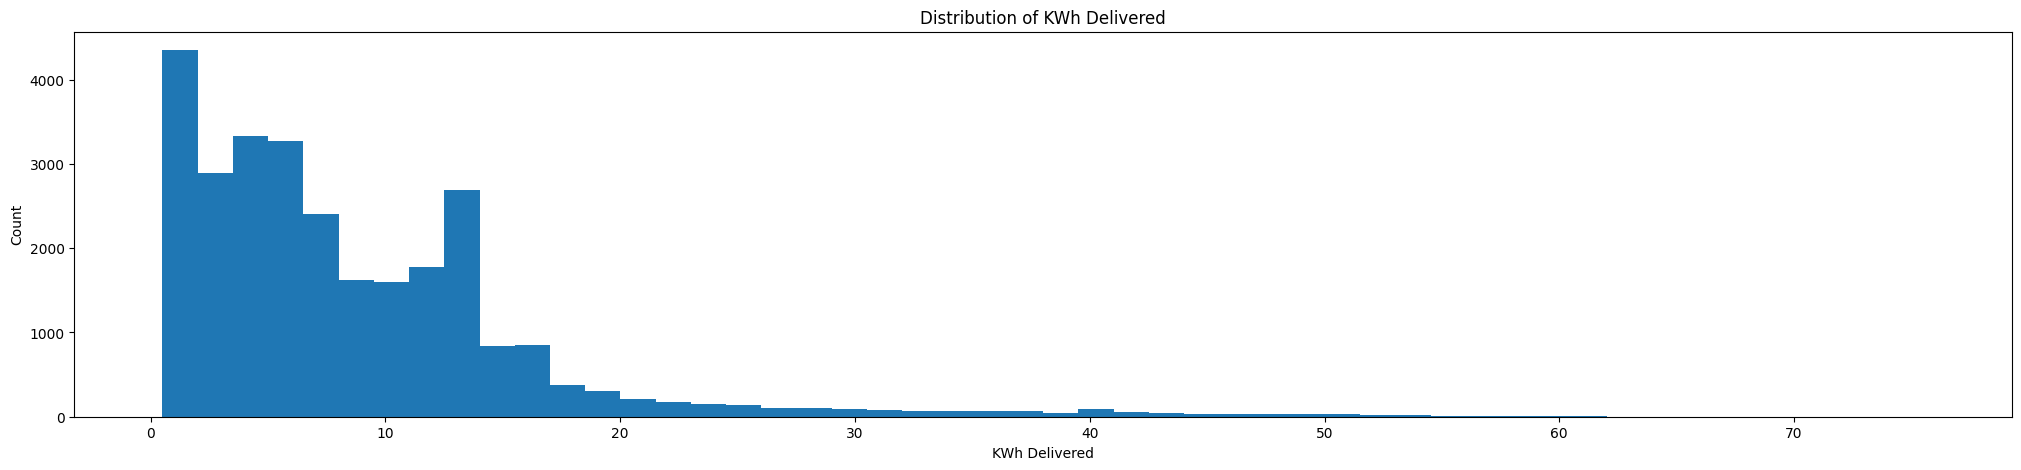

In [ ]:
plt.figure(figsize=(25, 5))
plt.hist(caltech_dataframe['kWhDelivered'], bins=50)
plt.xlabel('KWh Delivered')
plt.ylabel('Count')
plt.title('Distribution of KWh Delivered')
plt.show()

In [ ]:
fig = px.histogram(caltech_dataframe, x='kWhDelivered', nbins=50)
fig.update_layout(
    xaxis_title='KWh Delivered',
    yaxis_title='Count',
    title='Distribution of KWh Delivered'
)
fig.show()

In [ ]:
x = caltech_dataframe['total_charging_time']
percentiles = [8, 9, 10]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} Hour Charging Time is in the {percentile:.2f} percentile")

8 Hour Charging Time is in the 94.70 percentile
9 Hour Charging Time is in the 97.04 percentile
10 Hour Charging Time is in the 98.54 percentile


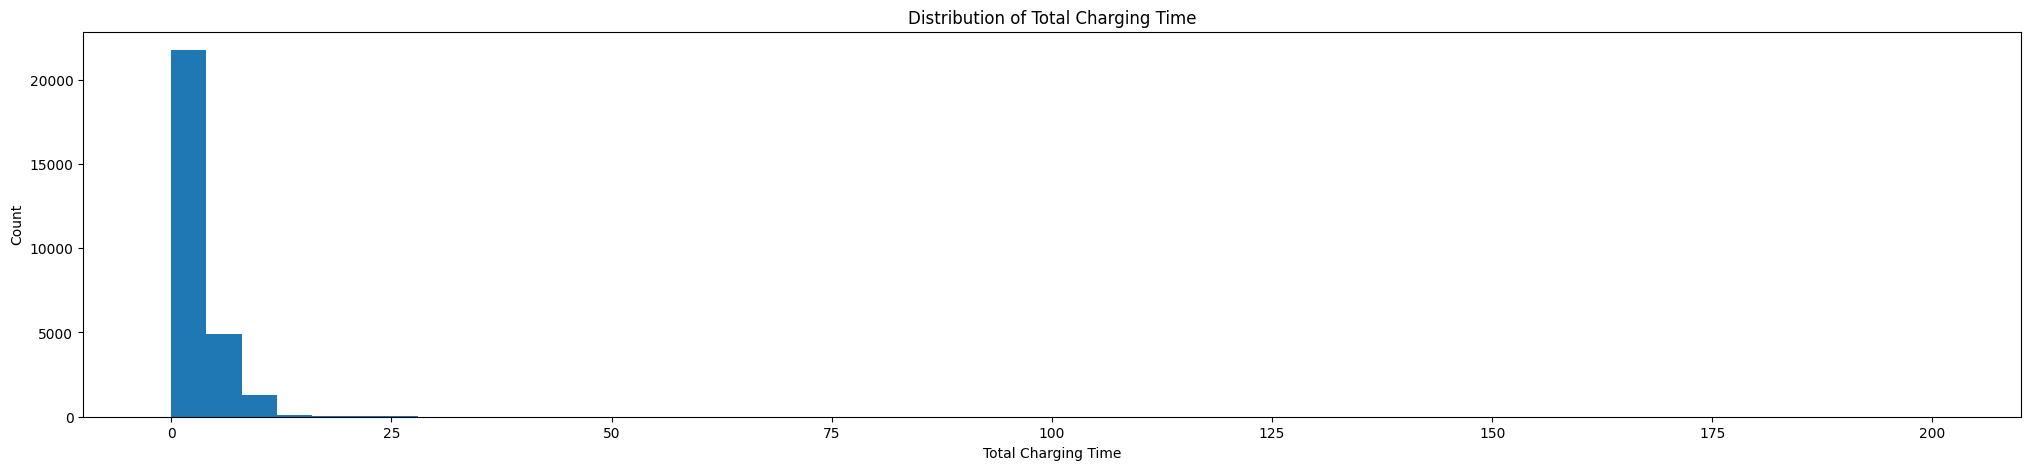

In [ ]:
plt.figure(figsize=(25, 5))
plt.hist(caltech_dataframe['total_charging_time'], bins=50)
plt.xlabel('Total Charging Time')
plt.ylabel('Count')
plt.title('Distribution of Total Charging Time')
plt.show()

In [ ]:
fig = px.histogram(caltech_dataframe, x='total_charging_time', nbins=50)
fig.update_layout(
    xaxis_title='Total Charging Time',
    yaxis_title='Count',
    title='Distribution of Total Charging Time'
)
fig.show()

In [ ]:
x = caltech_dataframe['idle_time']
percentiles = [10, 11, 12, 13, 24]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} Hour Idle Time is in the {percentile:.2f} percentile")

10 Hour Idle Time is in the 96.71 percentile
11 Hour Idle Time is in the 97.54 percentile
12 Hour Idle Time is in the 98.14 percentile
13 Hour Idle Time is in the 98.48 percentile
24 Hour Idle Time is in the 99.51 percentile


In [ ]:
fig = px.histogram(caltech_dataframe, x='idle_time', nbins=50)
fig.update_layout(
    xaxis_title='Total Idle Time',
    yaxis_title='Count',
    title='Distribution of Total Idle Time'
)
fig.show()

In [ ]:
caltech_dataframe_before_COVID = caltech_dataframe.loc[caltech_dataframe['connectionTime'] < pd.to_datetime('2020-03-15')]
caltech_dataframe_before_COVID.shape

(26012, 6)

**Removing Some outliers where kWhDelivered > 40, total_charging_time > 10 and idle_time > 12**

In [ ]:
caltech_dataframe_before_COVID = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID['kWhDelivered'] <= 40].reset_index(drop=True)
caltech_dataframe_before_COVID = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID['total_charging_time'] <= 10].reset_index(drop=True)
caltech_dataframe_before_COVID = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID['idle_time'] <= 12].reset_index(drop=True)
caltech_dataframe_before_COVID

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2018-04-25 06:45:10,10.013,2,9527,2.984722,8.200278
1,2018-04-25 06:45:50,5.257,2,79380,1.098333,8.216944
2,2018-04-25 07:37:06,5.177,2,79379,1.471111,7.836667
3,2018-04-25 07:40:34,10.119,2,79381,2.998889,5.378333
4,2018-04-25 07:43:50,7.910,2,13928,1.577222,8.983889
...,...,...,...,...,...,...
24859,2020-03-13 20:29:15,3.493,2,12521,1.015556,0.001389
24860,2020-03-14 15:10:09,4.421,2,12719,1.493889,0.393056
24861,2020-03-14 16:26:22,0.830,2,13130,0.504444,1.075278
24862,2020-03-14 17:57:31,3.868,2,12917,1.113056,0.001389


# Addressing duplicacy in `connectionTime`

**Checking how many duplicates are there for the same `connectionTime`**

In [ ]:
# Find the duplicated rows based on the 'connectionTime' column
duplicated_df = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID.duplicated(subset=['connectionTime'], keep=False)]

# Print the new DataFrame
duplicated_df

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
538,2018-05-07 13:47:50,2.536,2,123557,3.570833,10.126667
539,2018-05-07 13:47:50,14.295,2,95444,4.042778,0.001389
540,2018-05-07 13:47:50,1.585,2,12719,1.027222,3.926667
1009,2018-05-16 09:26:36,1.990,2,129563,0.977222,10.766111
1010,2018-05-16 09:26:36,2.772,2,78365,1.635556,5.799722
3281,2018-06-26 08:44:15,12.094,2,12521,5.251389,0.977222
3282,2018-06-26 08:44:15,21.117,2,90440,8.953056,0.165556
6019,2018-08-09 20:13:41,11.344,2,12818,1.765278,0.001944
6020,2018-08-09 20:13:41,5.958,2,12620,0.920278,0.001389
7273,2018-08-28 08:54:35,5.064,2,78365,2.401111,0.358056


**50 duplicates. We need to handle them**

In [ ]:
len(duplicated_df)

56

In [ ]:
caltech_dataframe_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24864 entries, 0 to 24863
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       24864 non-null  datetime64[ns]
 1   kWhDelivered         24864 non-null  float64       
 2   siteID               24864 non-null  int64         
 3   stationID            24864 non-null  int64         
 4   total_charging_time  24864 non-null  float64       
 5   idle_time            24864 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 1.1 MB


**The unique hours that we have duplicacy**

In [ ]:
unique_hours = duplicated_df['connectionTime'].dt.hour.unique()
unique_hours

array([13,  9,  8, 20, 18, 10, 12])

**At the given duplicate hours we are finding out the maximum occuring `stationID`for the whole time period.**

In [ ]:
df = caltech_dataframe_before_COVID.copy()
# First, make sure the connectionTime column is a datetime type
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

# Extract the hour from the connectionTime column
df['hour'] = df['connectionTime'].dt.hour

# Then, filter the DataFrame to only include rows with the hours of interest
df_filtered = df[df['hour'].isin(unique_hours)]

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size()

# Get the stationID with the highest count for each hour of interest
for hour in unique_hours:
    max_station = grouped[hour].idxmax()
    print(f"At hour {hour}, stationID {max_station} had the highest count.")

At hour 13, stationID 13928 had the highest count.
At hour 9, stationID 8925 had the highest count.
At hour 8, stationID 13130 had the highest count.
At hour 20, stationID 13928 had the highest count.
At hour 18, stationID 13928 had the highest count.
At hour 10, stationID 12422 had the highest count.
At hour 12, stationID 8824 had the highest count.


**Also sorting the occurance of `stationID` from highest to lowest for a particular hour (obviously duplicated unique hours)**

In [ ]:
unique_hours = duplicated_df['connectionTime'].dt.hour.unique()

df = caltech_dataframe_before_COVID.copy()
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['hour'] = df['connectionTime'].dt.hour
df_filtered = df[df['hour'].isin(unique_hours)]

grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

for hour in unique_hours:
    hour_df = grouped[grouped['hour'] == hour].sort_values('count', ascending=False)
    print(f"At hour {hour}, the occurrences of stationID from highest to lowest are:")
    for index, row in hour_df.iterrows():
        print(f"{row['stationID']}: {row['count']} occurrences")

At hour 13, the occurrences of stationID from highest to lowest are:
13928: 54 occurrences
79383: 53 occurrences
8824: 49 occurrences
91441: 46 occurrences
12323: 44 occurrences
12521: 44 occurrences
12422: 43 occurrences
78361: 42 occurrences
78367: 40 occurrences
78364: 39 occurrences
13130: 39 occurrences
88438: 38 occurrences
12719: 38 occurrences
12917: 38 occurrences
78360: 37 occurrences
13829: 37 occurrences
13031: 37 occurrences
92436: 36 occurrences
79377: 35 occurrences
78366: 34 occurrences
79378: 34 occurrences
92442: 33 occurrences
9026: 32 occurrences
78363: 32 occurrences
12818: 32 occurrences
78365: 30 occurrences
91437: 30 occurrences
9527: 30 occurrences
79380: 27 occurrences
79381: 26 occurrences
12620: 25 occurrences
8925: 24 occurrences
79376: 23 occurrences
95444: 22 occurrences
79379: 21 occurrences
79382: 21 occurrences
123557: 20 occurrences
89439: 19 occurrences
90440: 18 occurrences
83387: 12 occurrences
138566: 11 occurrences
130564: 9 occurrences
139567: 9

**The duplicates for stationID at the same time are handled by selecting the stationID with the highest count for each hour (if available). If no such stationID is found, random rows are selected to ensure a minimum number of samples (n_samples) for that hour.**

In [ ]:
n_samples = 1
# First, extract the hour from the connectionTime column
duplicated_df = duplicated_df.assign(hour=duplicated_df['connectionTime'].dt.hour)

# Filter the DataFrame to only include rows with the hours of interest
df_filtered = duplicated_df[duplicated_df['hour'].isin(unique_hours)]

# For each hour of interest, identify the stationID with the highest count and keep only the rows with that stationID
for hour in unique_hours:
    # Filter the DataFrame to only include rows for the current hour
    df_hour = df_filtered[df_filtered['hour'] == hour]
    # Group the DataFrame by stationID and count the occurrences of each
    grouped = df_hour.groupby('stationID').size().reset_index(name='count')
    # Sort the DataFrame by count in descending order
    grouped.sort_values('count', ascending=False, inplace=True)

    # Find the stationID with the highest count that is not already selected for this hour
    selected_stationID = None
    for stationID in grouped['stationID']:
        if not df_filtered[(df_filtered['hour'] == hour) & (df_filtered['stationID'] == stationID)].empty:
            selected_stationID = stationID
            break

    if selected_stationID is None:
        # If no stationID is found, pick random rows from the duplicated_df for this hour
        df_selected = df_filtered[df_filtered['hour'] == hour].sample(n=min(n_samples, len(df_filtered[df_filtered['hour'] == hour])), random_state=SEED)
    else:
        # Keep only the rows with the selected stationID for this hour
        df_selected = df_filtered[(df_filtered['hour'] != hour) | (df_filtered['stationID'] == selected_stationID)]

    # Add the selected rows to the final DataFrame
    if hour == unique_hours[0]:
        df_final = df_selected
    else:
        df_final = pd.concat([df_final, df_selected])

# Finally, remove duplicates based on connectionTime
df_final.drop_duplicates(subset='connectionTime', inplace=True)
selected_rows = df_final[df_final['connectionTime'] == '2018-05-07 13:47:50']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,hour
540,2018-05-07 13:47:50,1.585,2,12719,1.027222,3.926667,13


In [ ]:
df_final.shape

(20, 7)

In [ ]:
caltech_dataframe_before_COVID.shape

(24864, 6)

In [ ]:
selected_rows = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID['connectionTime'] == '2018-05-07 13:47:50']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
538,2018-05-07 13:47:50,2.536,2,123557,3.570833,10.126667
539,2018-05-07 13:47:50,14.295,2,95444,4.042778,0.001389
540,2018-05-07 13:47:50,1.585,2,12719,1.027222,3.926667


In [ ]:
# Drop all the duplicate rows based on the 'connectionTime' column from the original dataframe
caltech_dataframe_before_COVID.drop_duplicates(subset=['connectionTime'], keep=False, inplace=True)

In [ ]:
caltech_dataframe_before_COVID.shape

(24808, 6)

In [ ]:
selected_rows = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID['connectionTime'] == '2018-05-07 13:47:50']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time


In [ ]:
duplicates = caltech_dataframe_before_COVID.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')

There are no duplicates based on the connectionTime column.


In [ ]:
# Concatenate the selected_rows DataFrame to caltech_dataframe_before_COVID
caltech_dataframe_before_COVID = pd.concat([caltech_dataframe_before_COVID, df_final], ignore_index=True)
caltech_dataframe_before_COVID.shape

(24828, 7)

In [ ]:
caltech_dataframe_before_COVID

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,hour
0,2018-04-25 06:45:10,10.013,2,9527,2.984722,8.200278,NaN
1,2018-04-25 06:45:50,5.257,2,79380,1.098333,8.216944,NaN
2,2018-04-25 07:37:06,5.177,2,79379,1.471111,7.836667,NaN
3,2018-04-25 07:40:34,10.119,2,79381,2.998889,5.378333,NaN
4,2018-04-25 07:43:50,7.910,2,13928,1.577222,8.983889,NaN
...,...,...,...,...,...,...,...
24823,2019-05-14 09:56:27,6.511,2,78364,1.650833,0.001389,9.0
24824,2019-06-10 10:02:37,3.184,2,78365,6.298333,1.823056,10.0
24825,2019-06-12 12:05:04,3.467,2,79379,2.112500,0.001667,12.0
24826,2019-09-27 08:32:41,22.124,2,92442,3.472500,1.820000,8.0


In [ ]:
selected_rows = caltech_dataframe_before_COVID[caltech_dataframe_before_COVID['connectionTime'] == '2018-05-07 13:47:50']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,hour
24808,2018-05-07 13:47:50,1.585,2,12719,1.027222,3.926667,13.0


In [ ]:
# Drop the 'hour' column from the dataframe
caltech_dataframe_before_COVID.drop('hour', axis=1, inplace=True)

In [ ]:
caltech_dataframe_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24828 entries, 0 to 24827
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       24828 non-null  datetime64[ns]
 1   kWhDelivered         24828 non-null  float64       
 2   siteID               24828 non-null  int64         
 3   stationID            24828 non-null  int64         
 4   total_charging_time  24828 non-null  float64       
 5   idle_time            24828 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 1.1 MB


**Finally done! 😊**

In [ ]:
duplicates = caltech_dataframe_before_COVID.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')


There are no duplicates based on the connectionTime column.


# Isolation Forest - Anomaly detection

**Checked Isolation Forest. But seems not helpful that much! Still deciding to keep or not**

In [ ]:
features = ['kWhDelivered', 'total_charging_time', 'idle_time']

model = IsolationForest(n_estimators=100, max_samples='auto', contamination=0.1, verbose = False, max_features=3, random_state=SEED)
model.fit(caltech_dataframe_before_COVID[features].values)

IsolationForest(contamination=0.1, max_features=3, random_state=42,
                verbose=False)

In [ ]:
print(model.get_params())

{'bootstrap': False, 'contamination': 0.1, 'max_features': 3, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': 42, 'verbose': False, 'warm_start': False}


In [ ]:
caltech_dataframe_before_COVID['scores'] = model.decision_function(caltech_dataframe_before_COVID[features].values)
caltech_dataframe_before_COVID['anomaly'] = model.predict(caltech_dataframe_before_COVID[features].values)

In [ ]:
anomaly=caltech_dataframe_before_COVID.loc[caltech_dataframe_before_COVID['anomaly']==-1]
anomaly_index=list(anomaly.index)
anomaly

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,scores,anomaly
9,2018-04-25 08:14:41,3.249,2,91437,1.058333,10.131111,-0.008416,-1
26,2018-04-25 09:25:51,32.708,2,88438,6.080556,0.001389,-0.078634,-1
43,2018-04-25 18:21:28,1.020,2,78367,7.975556,2.186944,-0.043050,-1
52,2018-04-25 20:13:44,6.503,2,79378,2.314167,11.253611,-0.026709,-1
57,2018-04-26 06:54:17,7.108,2,79380,9.215278,0.020000,-0.015469,-1
...,...,...,...,...,...,...,...,...
24779,2020-03-12 09:48:56,3.627,2,12323,8.098889,0.311944,-0.014758,-1
24782,2020-03-12 10:19:04,1.134,2,12719,6.937500,0.939167,-0.015280,-1
24793,2020-03-13 08:34:24,1.473,2,79379,0.409722,9.308889,-0.028468,-1
24807,2020-03-14 22:58:50,29.647,2,90440,4.435556,7.880833,-0.115036,-1


In [ ]:
# Drop the rows with anomalies
caltech_dataframe_before_COVID = caltech_dataframe_before_COVID.loc[caltech_dataframe_before_COVID['anomaly'] != -1].copy()
# Drop the "anomaly" and "score" columns
caltech_dataframe_before_COVID.drop(columns=["anomaly", "scores"], inplace=True)

In [ ]:
caltech_dataframe_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22345 entries, 0 to 24827
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       22345 non-null  datetime64[ns]
 1   kWhDelivered         22345 non-null  float64       
 2   siteID               22345 non-null  int64         
 3   stationID            22345 non-null  int64         
 4   total_charging_time  22345 non-null  float64       
 5   idle_time            22345 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 1.2 MB


# Some visualization

**Some visualization. But not important!**

In [ ]:
# First, make sure the connectionTime column is a datetime type
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

# Extract the hour from the connectionTime column
df['hour'] = df['connectionTime'].dt.hour

# Then, filter the DataFrame to only include rows with the hours of interest
hours_of_interest = list(range(0, 24))
df_filtered = df[df['hour'].isin(hours_of_interest)]

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

# Get the stationID with the highest count for each hour of interest
for hour in hours_of_interest:
    df_hour = grouped[grouped['hour'] == hour]
    max_station = df_hour.loc[df_hour['count'].idxmax(), 'stationID']
    max_count = df_hour['count'].max()
    print(f"At hour {hour}, stationID {max_station} had the highest count with {max_count} occurrences.")


At hour 0, stationID 79380 had the highest count with 16 occurrences.
At hour 1, stationID 79380 had the highest count with 13 occurrences.
At hour 2, stationID 78365 had the highest count with 5 occurrences.
At hour 3, stationID 13928 had the highest count with 4 occurrences.
At hour 4, stationID 79383 had the highest count with 74 occurrences.
At hour 5, stationID 12719 had the highest count with 15 occurrences.
At hour 6, stationID 8925 had the highest count with 111 occurrences.
At hour 7, stationID 78366 had the highest count with 124 occurrences.
At hour 8, stationID 13130 had the highest count with 258 occurrences.
At hour 9, stationID 8925 had the highest count with 226 occurrences.
At hour 10, stationID 12422 had the highest count with 99 occurrences.
At hour 11, stationID 8824 had the highest count with 63 occurrences.
At hour 12, stationID 8824 had the highest count with 73 occurrences.
At hour 13, stationID 13928 had the highest count with 54 occurrences.
At hour 14, statio

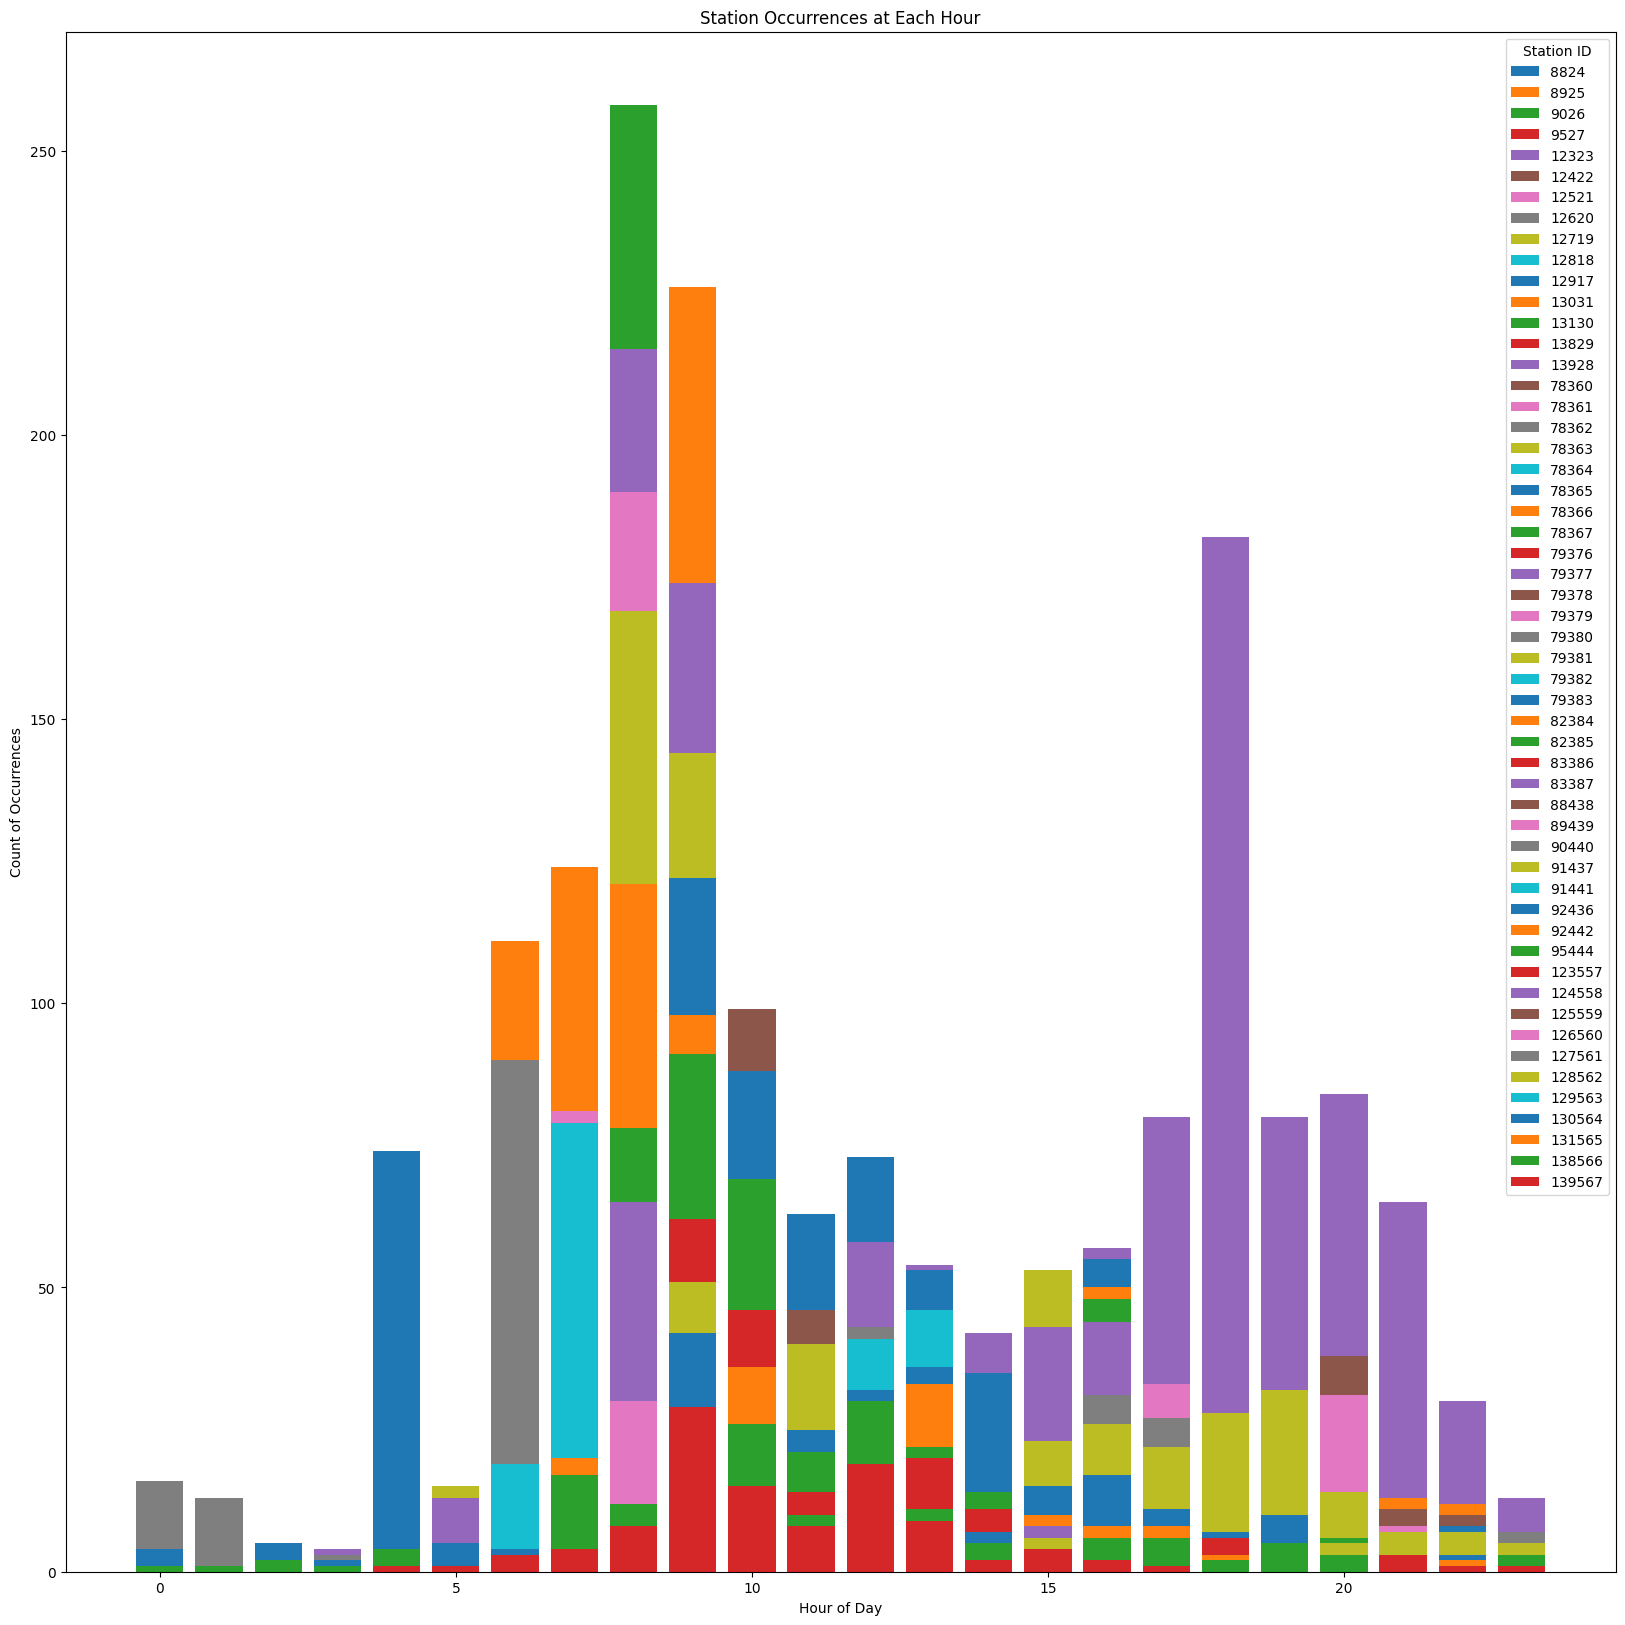

In [ ]:
import matplotlib.pyplot as plt

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

# Plot a histogram of the station occurrences at each hour
fig, ax = plt.subplots(figsize=(20, 20))
for name, group in grouped.groupby('stationID'):
    ax.bar(group['hour'], group['count'], label=name)

# Add labels and legend
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Count of Occurrences')
ax.set_title('Station Occurrences at Each Hour')
ax.legend(title='Station ID')
plt.show()

# Save the preprocessed Dataframe

In [ ]:
file_path = '../../../data/preprocessed/ACN/acn_caltech_0.2_0.1_with_stationID_22_06_2023.csv'
caltech_dataframe_before_COVID.to_csv(file_path, index=False)